In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torchviz import make_dot

In [2]:
df = pd.read_csv(r"C:\Users\AmitLuhar\training\dataset\weather\city_temperature.csv")

C:\Users\AmitLuhar\AppData\Local\Temp\ipykernel_18760\1672062046.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\AmitLuhar\training\dataset\weather\city_temperature.csv")


#### Data Cleaning

In [3]:
print(df.columns)
print(df.shape)
print(len(df[df['City'] == 'Delhi']))
print(df.isnull().sum())

Index(['Region', 'Country', 'State', 'City', 'Month', 'Day', 'Year',
       'AvgTemperature'],
      dtype='object')
(2906327, 8)
9265
Region                  0
Country                 0
State             1450990
City                    0
Month                   0
Day                     0
Year                    0
AvgTemperature          0
dtype: int64


In [4]:
delhi_df = df[df['City'] == 'Delhi'].copy()

In [5]:
delhi_df['Date'] = pd.to_datetime(delhi_df[['Year', 'Month', 'Day']])
delhi_df.set_index('Date', inplace=True)
delhi_df.sort_index(inplace=True)

In [6]:
temperature_series = delhi_df['AvgTemperature']
print(temperature_series.head())


Date
1995-01-01    50.7
1995-01-02    52.1
1995-01-03    53.8
1995-01-04    53.7
1995-01-05    54.5
Name: AvgTemperature, dtype: float64


In [7]:
data_to_scale = temperature_series.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_scale)
print(scaled_data[:5])
scaled_data.shape


[[0.73852985]
 [0.74543661]
 [0.75382338]
 [0.75333004]
 [0.75727676]]


(9265, 1)

In [8]:
time_step = 9

dataX, dataY = [], []
for i in range(len(scaled_data) - time_step - 1):
    a = scaled_data[i:(i + time_step), 0]
    dataX.append(a)
    dataY.append(scaled_data[i + time_step, 0])
X, y = np.array(dataX), np.array(dataY)

print(f"X: {X.shape} \ny: {y.shape}")

X: (9255, 9) 
y: (9255,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
print(f"Train: {X_train.shape} \nTest: {X_test.shape}")

Train: (7404, 9, 1) 
Test: (1851, 9, 1)


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [12]:
X_train_tensor = torch.from_numpy(X_train).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)

X_test_tensor = torch.from_numpy(X_test).float().to(device)
y_test_tensor = torch.from_numpy(y_test).float().to(device)

### Hyper Para Para meeeterr

In [13]:
input_size = 1
hidden_size = 64
num_layers = 1
output_size = 1
num_layers = 3
dropout_prob = 0.2
learning_rate = 0.001
batch_size = 64
num_epochs = 100

In [14]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [15]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob=0.2):
        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_prob
        )
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        
        return out

model = RNNModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=output_size,
    dropout_prob=dropout_prob
).to(device)

print(model)

RNNModel(
  (rnn): RNN(1, 64, num_layers=3, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [17]:
train_losses = []
model.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    for sequences, labels in train_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        outputs = model(sequences)
        loss = criterion(outputs.squeeze(), labels)

        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}')
        
print("\nTraining finished!")

Epoch [10/100], Loss: 0.008533
Epoch [20/100], Loss: 0.007498
Epoch [30/100], Loss: 0.006654
Epoch [40/100], Loss: 0.006027
Epoch [50/100], Loss: 0.005672
Epoch [60/100], Loss: 0.005485
Epoch [70/100], Loss: 0.005256
Epoch [80/100], Loss: 0.005111
Epoch [90/100], Loss: 0.005137
Epoch [100/100], Loss: 0.005110

Training finished!


In [18]:
model.eval()

with torch.no_grad():
    train_predict = model(X_train_tensor).cpu().numpy()
    test_predict = model(X_test_tensor).cpu().numpy()

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [19]:
y_test_actual = scaler.inverse_transform(y_test_tensor.cpu().numpy().reshape(-1, 1))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
test_mae = mean_absolute_error(y_test_actual, test_predict)
test_r2 = r2_score(y_test_actual, test_predict)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R²:   {test_r2:.4f}")

Test RMSE: 12.0161
Test MAE:  3.3430
Test R²:   0.5690


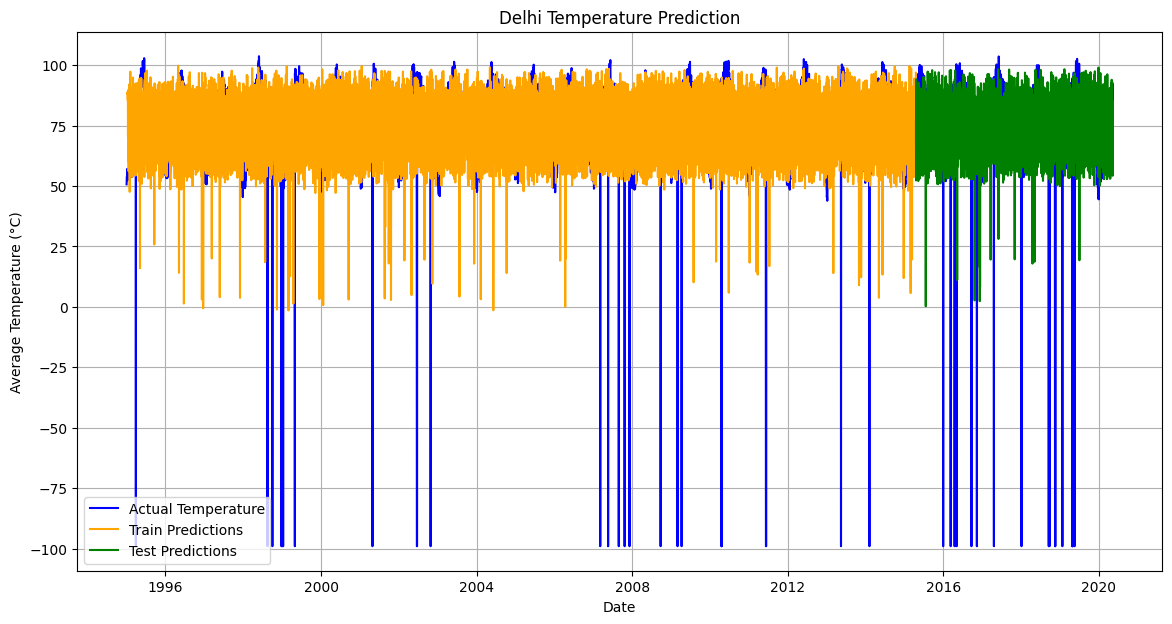

In [20]:
plot_shape = (len(temperature_series), 1)
train_plot = np.full(plot_shape, np.nan)
test_plot = np.full(plot_shape, np.nan)
start_train = time_step
end_train = start_train + len(train_predict)
train_plot[start_train:end_train, :] = train_predict
start_test = end_train
end_test = start_test + len(test_predict)
test_plot[start_test:end_test, :] = test_predict
plt.figure(figsize=(14, 7))
plt.plot(delhi_df.index, scaler.inverse_transform(scaled_data), label='Actual Temperature', color='blue')
plt.plot(delhi_df.index, train_plot, label='Train Predictions', color='orange')
plt.plot(delhi_df.index, test_plot, label='Test Predictions', color='green')

plt.title('Delhi Temperature Prediction')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()
